# Model SARIMA - Sèrie temporal 3

Aquest notebook analitza la sèrie temporal de casos de pneumònia en població de 15 anys o més a la regió BCN Nord, a partir de dades setmanals del període 2012–2024; utilitzant la metodologia Box-Jenkins.
L’objectiu és obtenir prediccions per al període d’avaluació i valorar-ne el comportament mitjançant mètriques d’error i cobertura dels intervals de predicció.

El procediment és el següent:

1. Identificació del model
2. Estimació del model
3. Validació
4. Predicció

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore', category=DeprecationWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

In [2]:
df_serie = df[
    (df["diagnostic"] == "PneumÃ²nia") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "15+")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

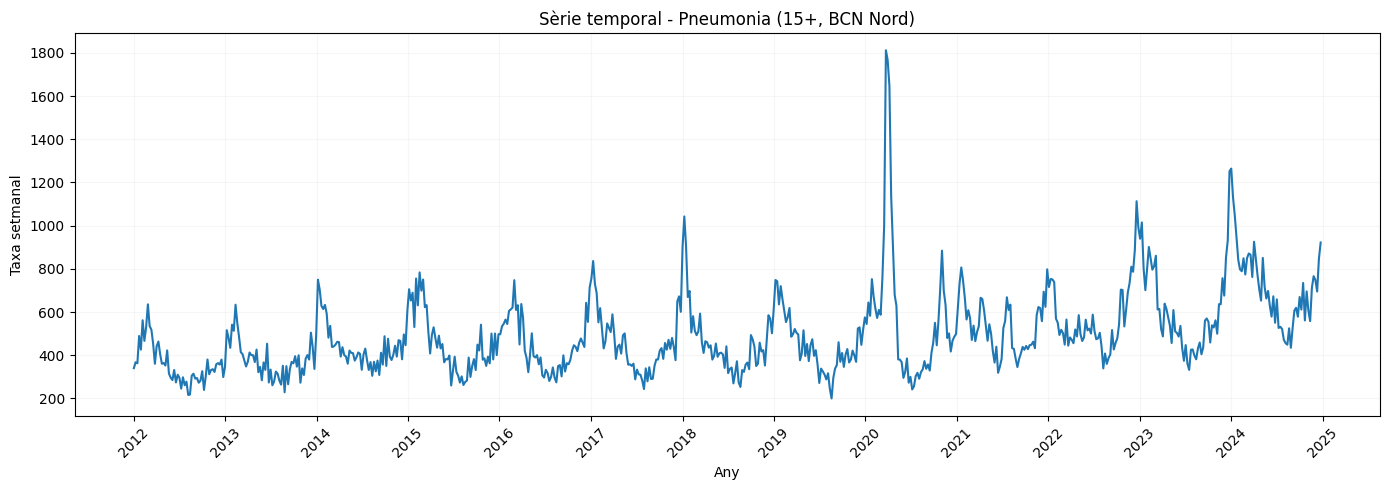

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Sèrie temporal - Pneumonia (15+, BCN Nord)")
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

## Divisió Entrenament-Avaluació

La sèrie es divideix en un conjunt d’entrenament (període 2012-2019) i un conjunt d’avaluació (període 2020-2024)

In [4]:
serie_3 = serie.copy()

train = serie_3[serie_3.index < "2020-01-01"]
test  = serie_3[serie_3.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

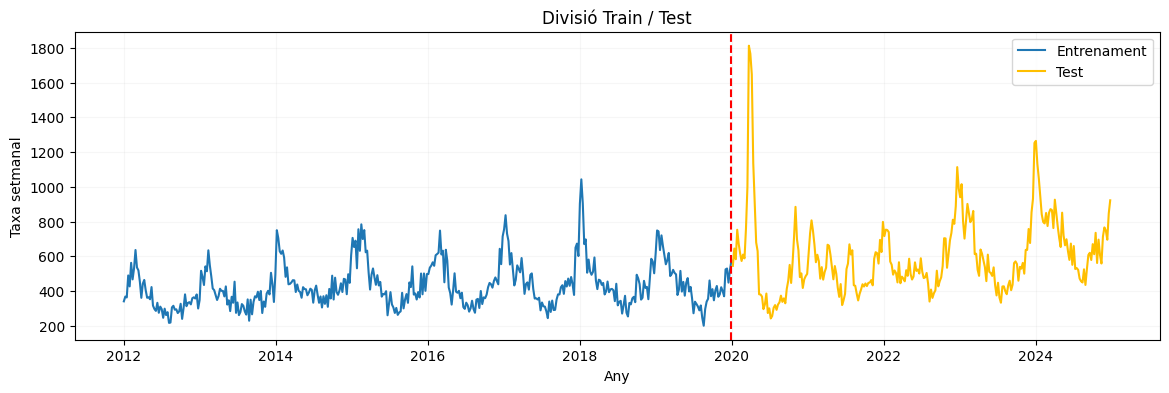

In [5]:
plt.figure(figsize=(14,4))

plt.plot(train, label="Entrenament", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)
plt.ylabel("Taxa setmanal")
plt.xlabel("Any")

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Divisió Train / Test")
plt.grid(alpha=0.1)
plt.show()

## Identificació del model

En aquesta fase s’analitza la sèrie d’entrenament per determinar les transformacions necessàries i proposar un conjunt reduït de models SARIMA candidats. Es considera l’estabilitat de la mitjana i la variància, la presència d’estacionalitat anual i la necessitat de diferenciació regular i estacional. Finalment, s’analitzen l’ACF i la PACF de la sèrie transformada per identificar els ordres del model.

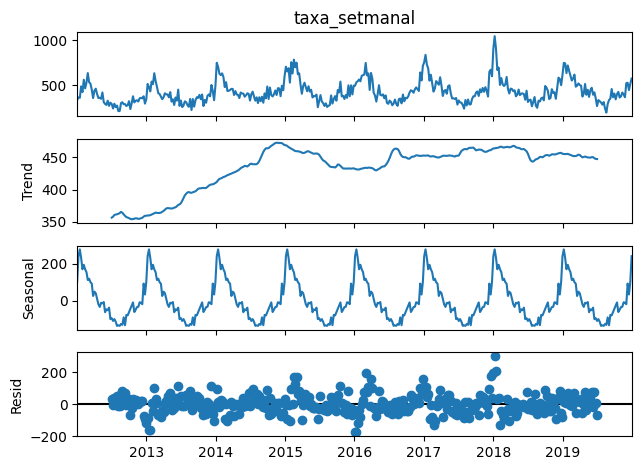

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()


### Transformació logarítmica

Es comparen la sèrie original i la sèrie transformada logarítmicament, juntament amb la seva mitjana i variància mòbils. Com que la variabilitat és més elevada en els períodes amb valors més alts, s’utilitza la transformació logarítmica per estabilitzar parcialment la variància.

Mitjana global (train): 429.12393552200444
Variància global (train): 15736.346409409314

Mitjana per any:
date
2012-12-31    356.493275
2013-12-31    380.345383
2014-12-31    440.240085
2015-12-31    452.511393
2016-12-31    446.004588
2017-12-31    450.860032
2018-12-31    460.780088
2019-12-31    446.544613
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31     8141.644983
2013-12-31     7281.025019
2014-12-31     9465.983945
2015-12-31    19708.249724
2016-12-31    14856.033179
2017-12-31    17807.082087
2018-12-31    24364.637055
2019-12-31    15690.858019
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


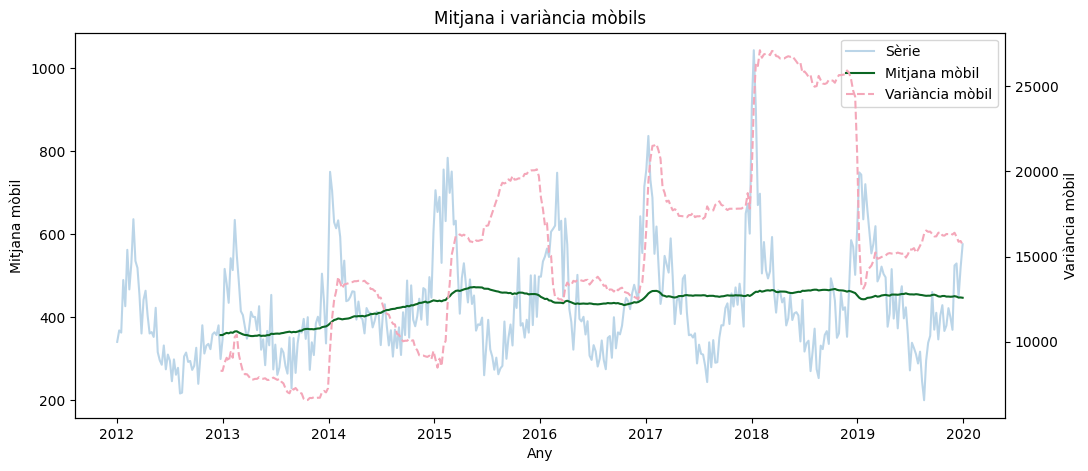

In [7]:
print("Mitjana global (train):", train.mean())
print("Variància global (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\nMitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_mean, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')
ax1.set_xlabel("Any")
ax1.set_ylabel("Mitjana mòbil")
ax2.set_ylabel("Variància mòbil")

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Mitjana i variància mòbils")
plt.show()

Mitjana global (train_log): 6.025698138775522
Variància global (train_log): 0.07445753390920708

 Mitjana per any:
date
2012-12-31    5.850479
2013-12-31    5.919982
2014-12-31    6.068587
2015-12-31    6.072791
2016-12-31    6.067451
2017-12-31    6.073352
2018-12-31    6.089585
2019-12-31    6.065499
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variància per any:
date
2012-12-31    0.056472
2013-12-31    0.047995
2014-12-31    0.040504
2015-12-31    0.088282
2016-12-31    0.070663
2017-12-31    0.079923
2018-12-31    0.085568
2019-12-31    0.079221
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


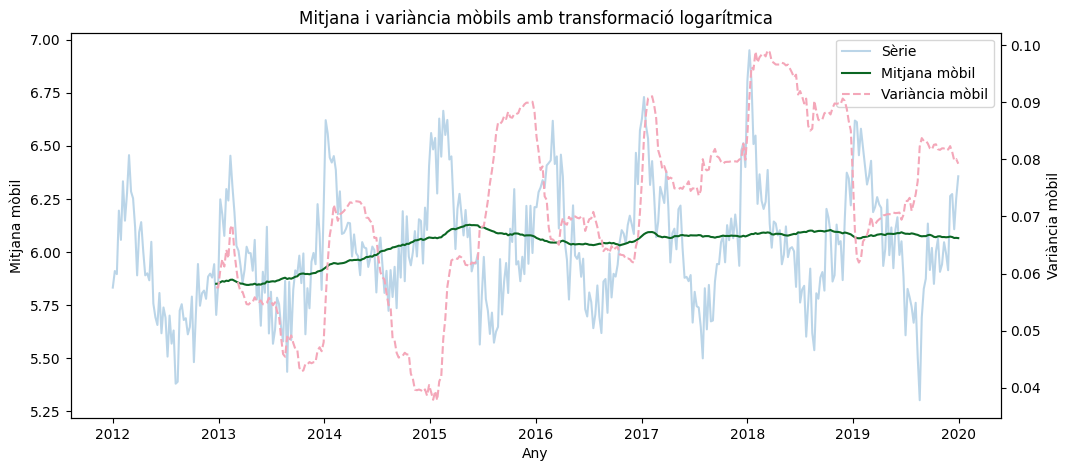

In [8]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print("Mitjana global (train_log):", train_log.mean())
print("Variància global (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\n Mitjana per any:")
print(yearly_mean)

print("\nVariància per any:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Sèrie')
l2, = ax1.plot(rolling_meanlog, label='Mitjana mòbil', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Variància mòbil', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

ax1.set_xlabel("Any")
ax1.set_ylabel("Mitjana mòbil")
ax2.set_ylabel("Variància mòbil")
plt.title("Mitjana i variància mòbils amb transformació logarítmica")
plt.show()

### ACF i diferenciació estacional

A continuació, s’analitza l’ACF de la sèrie logarítmica.
Els pics en retards propers al període anual, m=52, indiquen una dependència estacional clara.

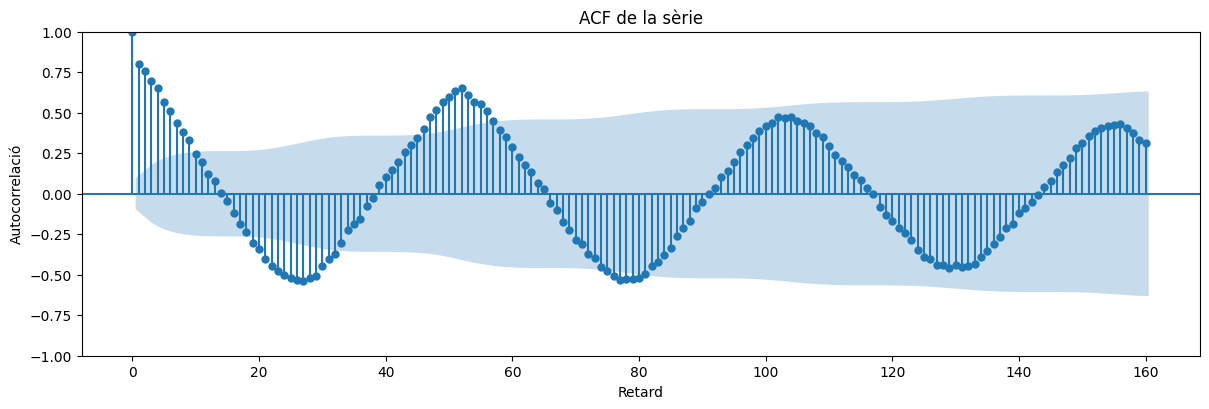

In [9]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF de la sèrie")
plt.tight_layout()
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")

plt.show()

Per comprovar l’efecte de la diferenciació estacional, es compara la sèrie abans i després d’aplicar D=1, així com les seves ACF corresponents. Després de la diferenciació estacional, la dependència anual es redueix de manera substancial. Per tant, es fixa D=1 amb període m=52.

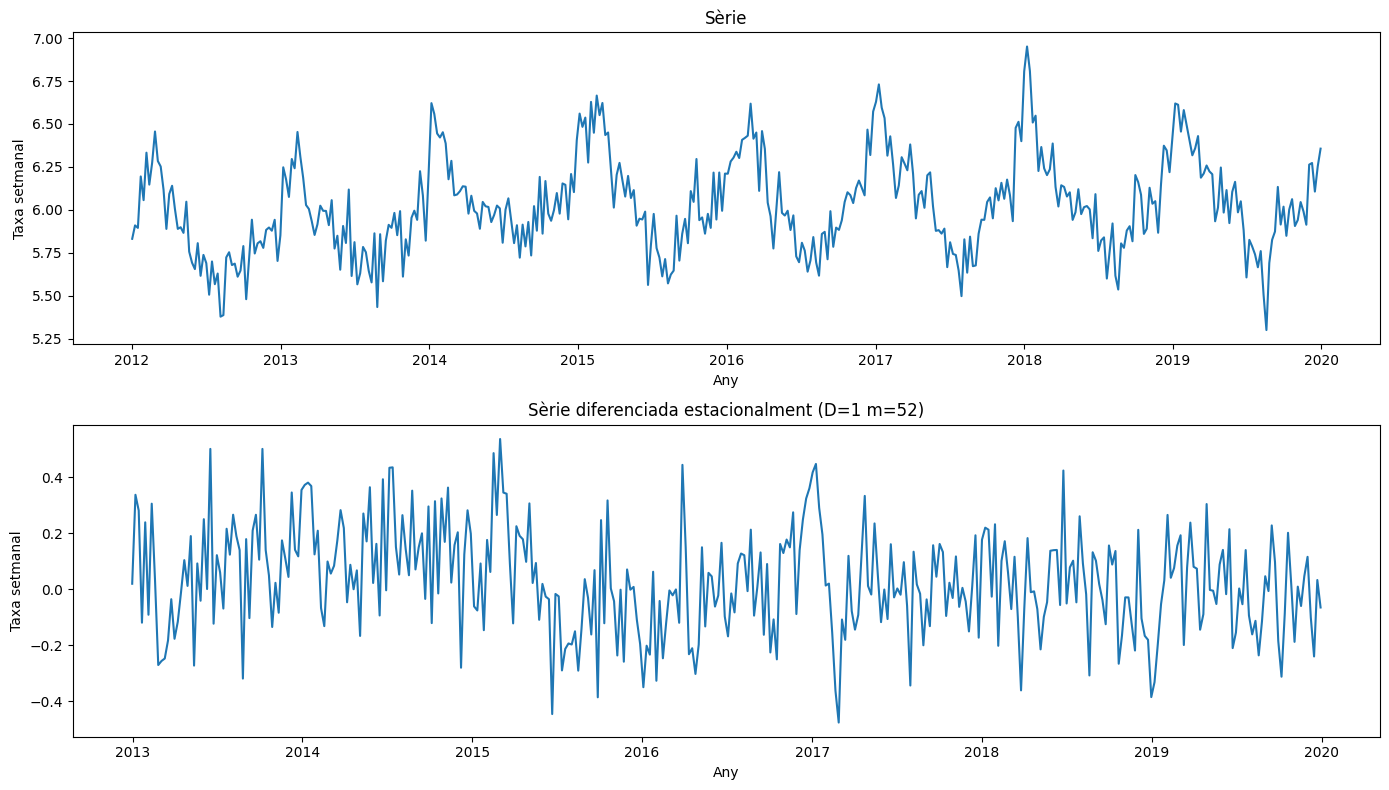

In [10]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Sèrie")
axes[0].set_ylabel("Taxa setmanal")
axes[0].set_xlabel("Any")

axes[1].plot(serie_D1)
axes[1].set_title("Sèrie diferenciada estacionalment (D=1 m=52)")
axes[1].set_ylabel("Taxa setmanal")
axes[1].set_xlabel("Any")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

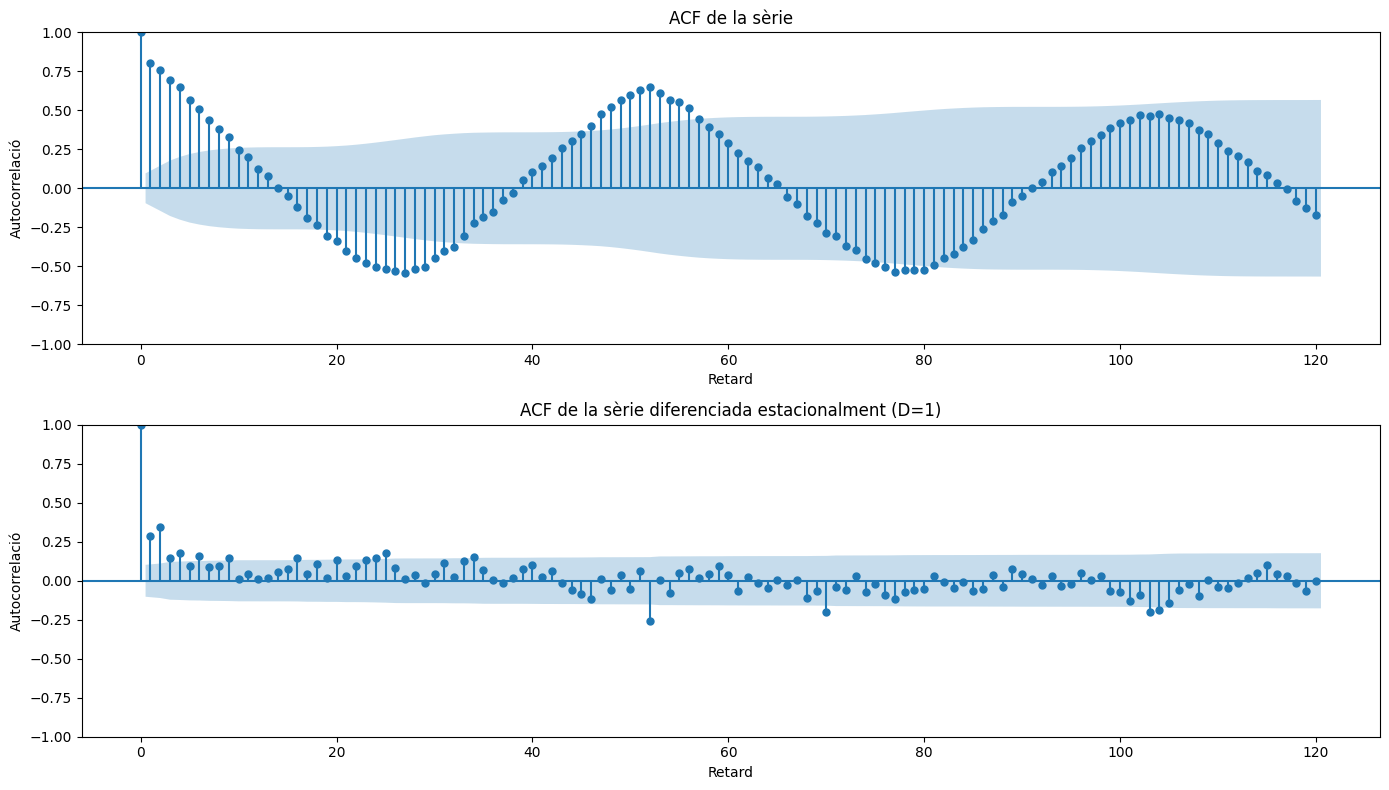

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF de la sèrie")
axes[0].set_xlabel("Retard")
axes[0].set_ylabel("Autocorrelació")


plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF de la sèrie diferenciada estacionalment (D=1)")
axes[1].set_xlabel("Retard")
axes[1].set_ylabel("Autocorrelació")


plt.tight_layout()
plt.show

### Comprovació de la diferenciació regular

Un cop considerada la transformació logarítmica i la diferenciació estacional, s’avalua si també és necessària una diferenciació regular. Aquesta decisió es basa en si la mitjana és constant, en l'ACF i es reforça mitjançant els tests ADF i KPSS.

In [12]:
adf_pvalor = adfuller(train_log, autolag="AIC")[1]
kpss_pvalor = kpss(train_log, regression="c", nlags="auto")[1]

def format_pvalor(p, test):
    if test == "ADF" and p < 0.001:
        return "< 0.001"
    if test == "KPSS" and p >= 0.10:
        return "> 0.10"
    return f"{p:.4f}"

conclusio_adf = (
    "Es rebutja H0: evidència d’estacionarietat"
    if adf_pvalor < 0.05
    else "No es rebutja H0: possible no estacionarietat"
)

conclusio_kpss = (
    "No es rebutja H0: compatible amb estacionarietat"
    if kpss_pvalor >= 0.05
    else "Es rebutja H0: evidència de no estacionarietat"
)

taula_tests = pd.DataFrame({
    "Test": ["ADF", "KPSS"],
    "p-valor": [
        format_pvalor(adf_pvalor, "ADF"),
        format_pvalor(kpss_pvalor, "KPSS")
    ],
    "Conclusió": [conclusio_adf, conclusio_kpss]
})

taula_tests

/var/folders/gl/4q3h26mn17x5r3shw8dj8t280000gn/T/ipykernel_3398/1130111050.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalor = kpss(train_log, regression="c", nlags="auto")[1]


,Test,p-valor,Conclusió
0,ADF,< 0.001,Es rebutja H0: evidència d’estacionarietat
1,KPSS,> 0.10,No es rebutja H0: compatible amb estacionarietat


Els resultats dels tests no indiquen la necessitat d’aplicar una diferenciació regular. Per tant, es fixa \(d=0\).

### Identificació dels ordres ARMA

Un cop seleccionades la transformació logarítmica i la diferenciació regular i estacional (d=0, D=1), s’analitzen l’ACF i la PACF de la sèrie resultant. A partir d’aquests gràfics es proposen ordres regulars baixos per als components AR i MA, i es consideren també components estacionals simples.

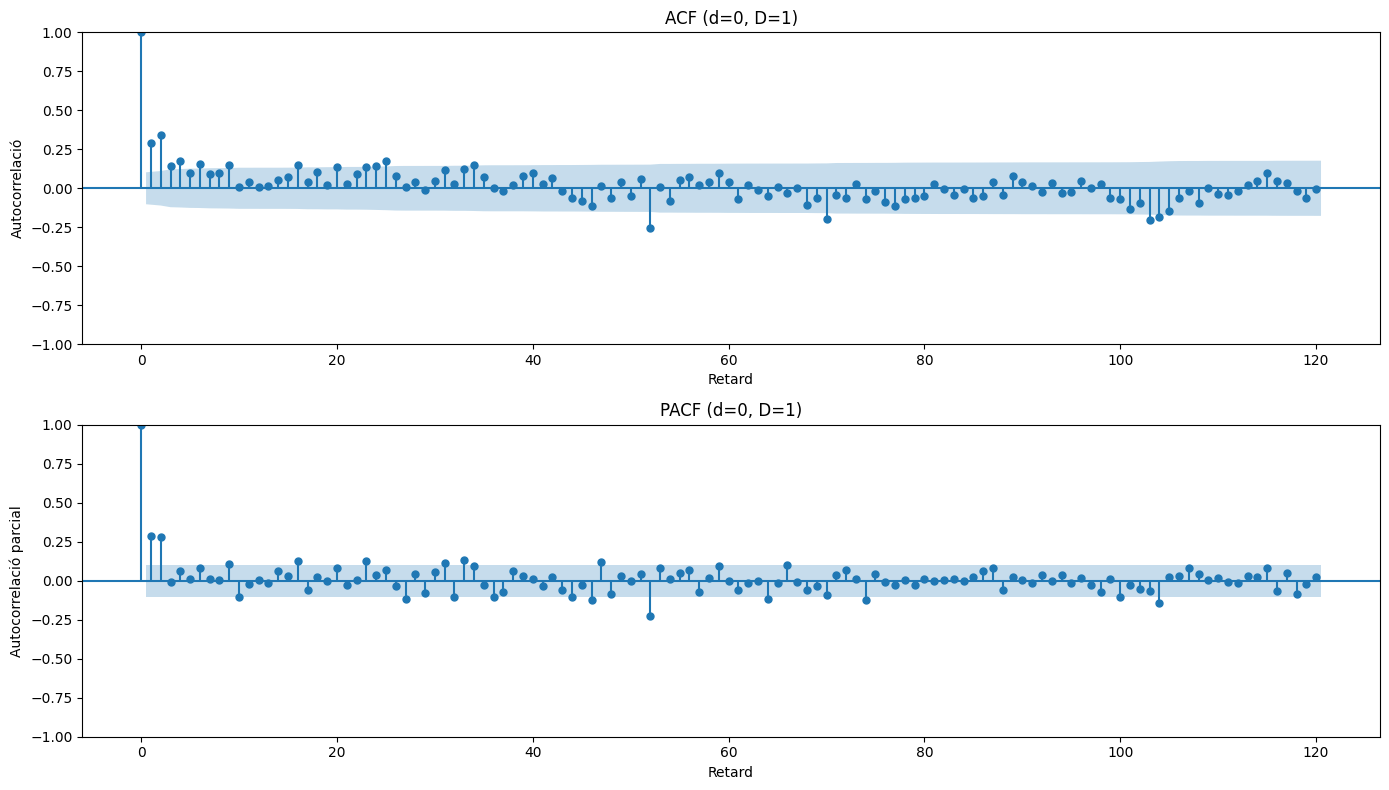

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_D1, lags=120, ax=axes[0])
axes[0].set_title("ACF (d=0, D=1)")
axes[0].set_xlabel("Retard")
axes[0].set_ylabel("Autocorrelació")

plot_pacf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("PACF (d=0, D=1)")
axes[1].set_xlabel("Retard")
axes[1].set_ylabel("Autocorrelació parcial")

plt.tight_layout()
plt.show()

## Anàlisi de l’ACF i la PACF

L’ACF i la PACF de la sèrie transformada, amb diferenciació estacional (D=1) i sense diferenciació regular (d=0), mostren una dependència a curt termini i una estructura estacional ja força reduïda. L’ACF suggereix la presència d’un component de mitjana mòbil, mentre que la PACF indica una possible component autoregressiva de primer ordre. Per aquest motiu, es consideren models SARIMA amb ordres regulars baixos i amb un component MA estacional.

## Estimació dels models candidats

S’ajusten diversos models SARIMA candidats a partir dels ordres identificats amb l’ACF i la PACF. La primera comparació es fa mitjançant l’AIC, amb l’objectiu de retenir un conjunt reduït de models per a la validació residual posterior. 

In [14]:
models = [
    ((1,0,1), (0,1,1,52)),
    ((1,0,0), (0,1,1,52)),
    ((2,0,0), (0,1,1,52)),
    ((2,0,1), (0,1,1,52)),
    ((1,0,0), (1,1,1,52)),
    ((1,0,1), (0,1,0,52)),
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA {order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA {order}{seasonal_order}")


print("\n Millor model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA (1, 0, 1)(0, 1, 1, 52)
AIC: -311.2546056299011
----------------------------------------
Model SARIMA (1, 0, 0)(0, 1, 1, 52)
AIC: -280.01200484977335
----------------------------------------
Model SARIMA (2, 0, 0)(0, 1, 1, 52)
AIC: -301.67872924987705
----------------------------------------
Model SARIMA (2, 0, 1)(0, 1, 1, 52)
AIC: -311.03450908864403
----------------------------------------
Model SARIMA (1, 0, 0)(1, 1, 1, 52)
AIC: -258.21102240981213
----------------------------------------
Model SARIMA (1, 0, 1)(0, 1, 0, 52)
AIC: -238.72094552538695
----------------------------------------

 Millor model:
((1, 0, 1), (0, 1, 1, 52))
AIC: -311.2546056299011


### Selecció preliminar de models

No es selecciona automàticament el model amb menor AIC. Es retenen els dos models amb menor AIC per comparar-ne també la significació dels coeficients, la parsimònia i el comportament dels residus.

In [15]:
model1 = SARIMAX(train_log,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 52)   Log Likelihood                 159.627
Date:                            Mon, 08 Jun 2026   AIC                           -311.255
Time:                                    20:50:19   BIC                           -296.283
Sample:                                01-02-2012   HQIC                          -305.271
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8747      0.038     23.295      0.000       0.801       0.948
ma.L1         -0.5897      0.071   

In [16]:
model2 = SARIMAX(train_log,
                order=(2,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2= model2.fit()
print(result2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 1)x(0, 1, 1, 52)   Log Likelihood                 160.517
Date:                            Mon, 08 Jun 2026   AIC                           -311.035
Time:                                    20:50:38   BIC                           -292.319
Sample:                                01-02-2012   HQIC                          -303.555
                                     - 12-30-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2689      0.067     18.998      0.000       1.138       1.400
ar.L2         -0.2804      0.063   

## Validació dels models preseleccionats

Els dos models preseleccionats s’avaluen mitjançant el diagnòstic dels residus. Es compara el gràfic dels residus, l’ACF dels residus i el contrast de Ljung-Box per retards regulars i estacionals per valorar si els residus es poden considerar aproximadament soroll blanc.

Burn-in utilitzats: 106


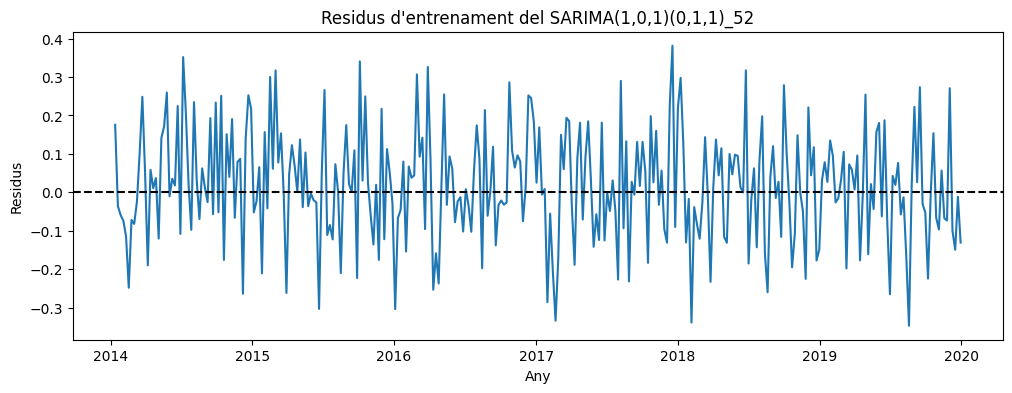

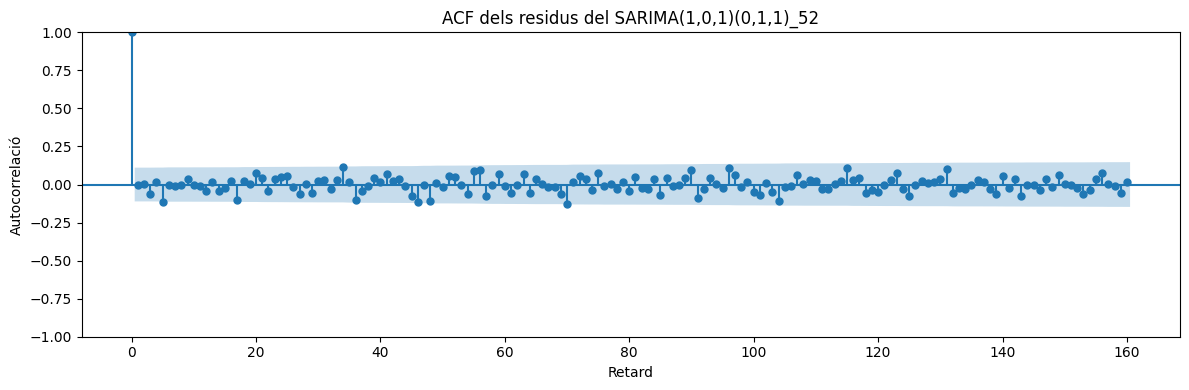


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10   5.780127   0.565645
20  13.006013   0.735783
30  19.222756   0.861742

Test de Ljung-Box en retards estacionals:
       lb_stat  lb_pvalue
52    45.70540   0.607488
104  109.14963   0.272492

Mitjana dels residus: 0.017297599335234472


In [17]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in utilitzats: {burn}")
residual1 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual1)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(1,0,1)(0,1,1)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual1, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(1,0,1)(0,1,1)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")

plt.tight_layout()
plt.show()


model_df = 1 + 1 + 0 + 1

ljung_box = acorr_ljungbox(
    residual1,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual1,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual1.mean())

Burn-in utilitzat: 106


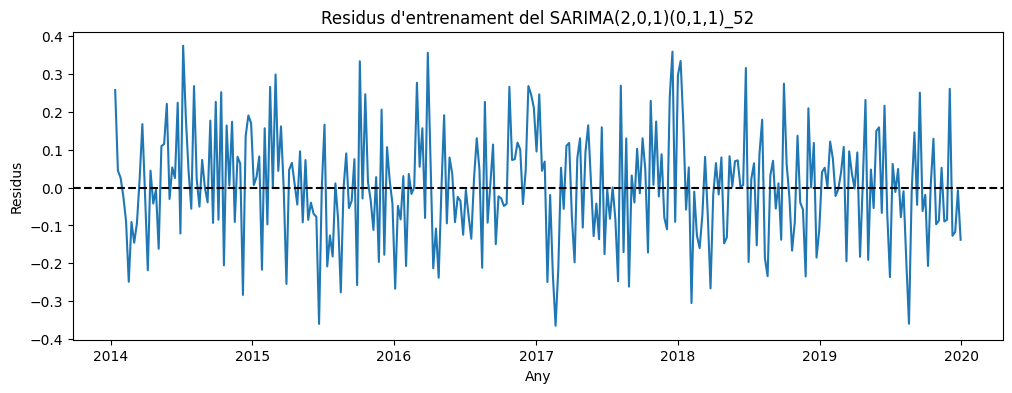

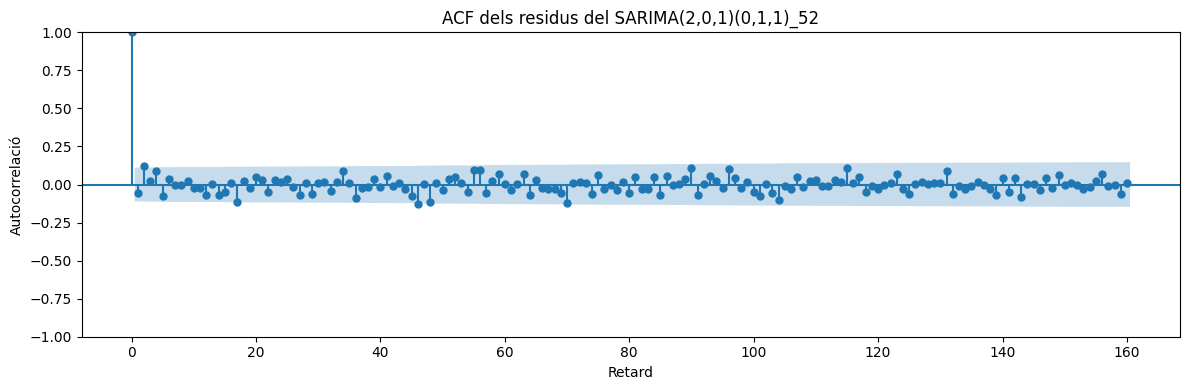


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10  11.061124   0.086506
20  20.562764   0.195936
30  25.665663   0.481596

Test de Ljung-Box en retards estacionals:
        lb_stat  lb_pvalue
52    49.501709   0.413079
104  111.690685   0.199560

Mitjana dels residus: 0.00328307836035222


In [18]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(12, 4))
plt.plot(residual2)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(2,0,1)(0,1,1)_52")
plt.xlabel("Any")
plt.ylabel("Residus")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residual2, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(2,0,1)(0,1,1)_52")
ax.set_xlabel("Retard")
ax.set_ylabel("Autocorrelació")

plt.tight_layout()
plt.show()


model_df = 2 + 1 + 0 + 1

ljung_box = acorr_ljungbox(
    residual2,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residual2,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

print("\nMitjana dels residus:", residual2.mean())

### Elecció del model final

Tot i que el diagnòstic dels residus mostra un comportament adequat pels dos models. Se selecciona el SARIMA(1,0,1)(0,1,1)_{52}, ja que presenta el menor AIC mantenint una estructura senzilla.


## Predicció SARIMA

Amb el model final seleccionat, es generen prediccions per al període 2020-2024 i es comparen amb els valors observats mitjançant el MAE, el RMSE i la cobertura dels intervals de predicció.

In [19]:
model = SARIMAX(train_log,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log)

In [20]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)
cov_total = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)
cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)
cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

table_total = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_total],
    "RMSE": [rmse_total],
    "Cobertura": [cov_total]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

table_covid = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_covid],
    "RMSE": [rmse_covid],
    "Cobertura": [cov_covid]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

table_post = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [mae_post],
    "RMSE": [rmse_post],
    "Cobertura": [cov_post]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

print("\nTOTAL (2020-2024):")
display(table_total)

print("\nCOVID (2020–2021):")
display(table_covid)

print("\nPOST-COVID (2022–2024):")
display(table_post)


TOTAL (2020-2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,175.308,247.253,0.604



COVID (2020–2021):


,Model,MAE,RMSE,Cobertura
0,SARIMA,147.08,272.912,0.75



POST-COVID (2022–2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,194.127,228.551,0.506


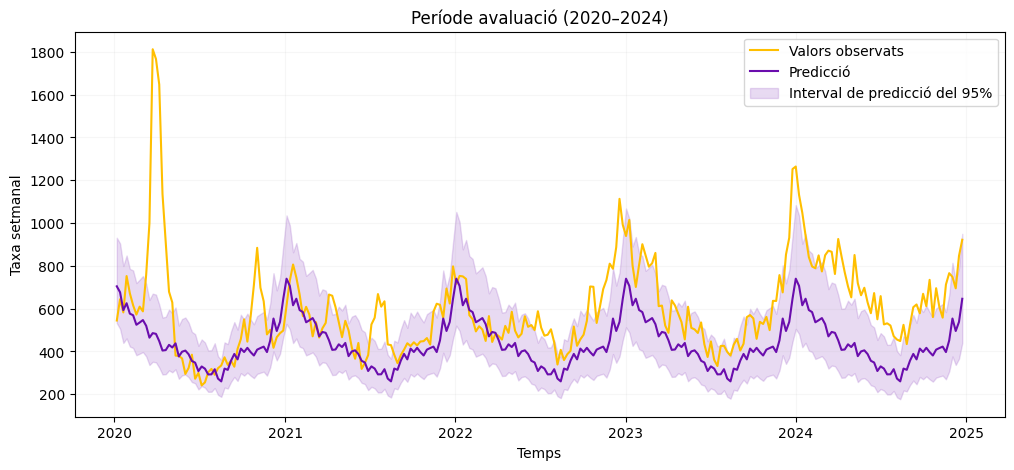

In [21]:
plt.figure(figsize=(12,5))

plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període avaluació (2020–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()

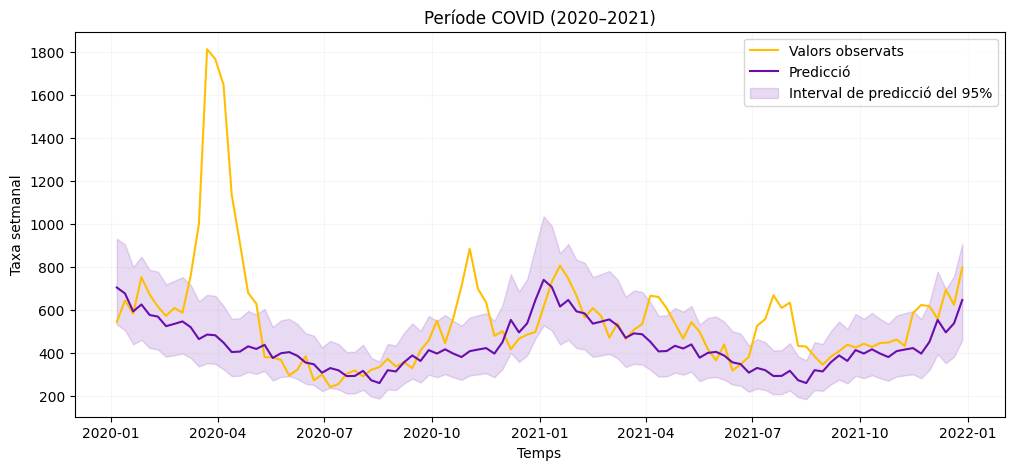

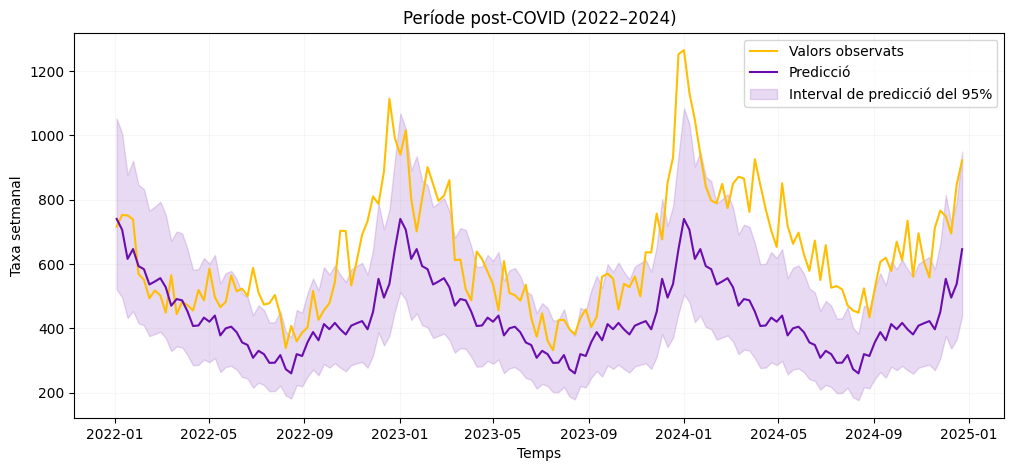

In [22]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període COVID (2020–2021)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.title("Període post-COVID (2022–2024)")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

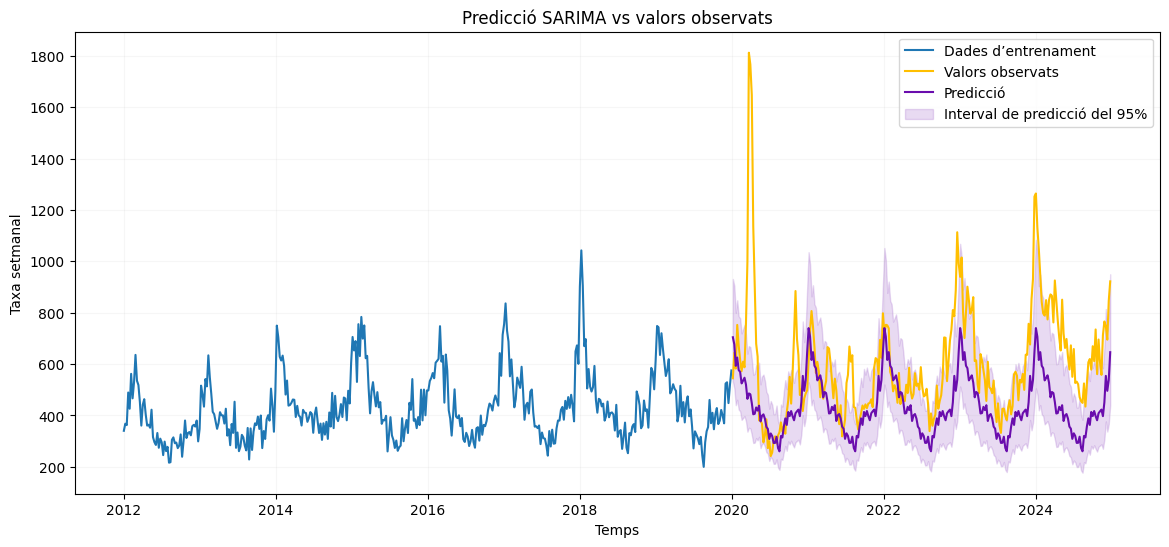

In [23]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Dades d’entrenament', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='Interval de predicció del 95%')

plt.legend()
plt.title("Predicció SARIMA vs valors observats")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.grid(alpha=0.1)
plt.show()